In [1]:
# This python notebook will create a CNN for predicting steering angles from a central dashcam in normal lighting conditions, then it will
# test the model under varying lighting conditions

# Then the notebook will create a CNN trained on varying lighting conditions and test the model under the same varying conditions

In [2]:
#Importing the required libraries
import os
print("OS Imported")
import numpy as np
print("Numpy Imported")
import pandas as pd
print("Pandas Imported")
import cv2
print("cv2 Imported")
import matplotlib.pyplot as plt
print("Matplotlib Imported")
from sklearn.model_selection import train_test_split
print("Sklearn Model Selection Imported")
from sklearn.metrics import mean_squared_error, r2_score
print("Sklearn metrics Imported")
from tensorflow.keras.models import Sequential
print("keras models Imported")
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input
print("keras layers Imported")
from tensorflow.keras.optimizers import Adam
print("keras optimizers Imported")
from tensorflow.keras.callbacks import EarlyStopping
print("keras callbacks Imported")
import random
print("random Imported")
print("All libraries are successfully loaded")

OS Imported
Numpy Imported
Pandas Imported
cv2 Imported
Matplotlib Imported
Sklearn Model Selection Imported
Sklearn metrics Imported
keras models Imported
keras layers Imported
keras optimizers Imported
keras callbacks Imported
random Imported
All libraries are successfully loaded


In [3]:
# Currently the images that I am using are from https://www.kaggle.com/datasets/andy8744/udacity-self-driving-car-behavioural-cloning, I 
# used the road and not the jungle dataset.

# One problem with this approach is that the images were for windows files and I am using a macbook, hence i needed to re-write the image
# paths

#My file paths
datasetCsvPath = "/Users/redsparrow/Desktop/Coding/LumierePaper/driving_log.csv"
imgFolder = "/Users/redsparrow/Desktop/Coding/LumierePaper/IMG/"

#loading the dataset with custom column names
column = ['center', 'left', 'right', 'steeringAngle', 'throttle', 'reverse', 'speed']
df = pd.read_csv(datasetCsvPath, header=None, names=column)

def fixPath(x):
    x = x.replace("\\", "/")
    return os.path.join(imgFolder, os.path.basename(x))

df['center'] = df['center'].apply(fixPath)
df['left']   = df['left'].apply(fixPath)
df['right']  = df['right'].apply(fixPath)

In [4]:
# The vast majority of the dataset consists of straight angle (ie: between -0.05 and 0.05 degrees, resulting 
# in no change to the steering angle).
# Through testing the model learnt that guessing 0.0 had the highest rate of success, as turns were rare. 
# For this reason, I am discarding the majority of the straight images.

# Separate turning and straight images
dfTurns = df[df['steeringAngle'].abs() > 0.05]
dfStraight = df[df['steeringAngle'].abs() <= 0.05]

# Keep roughly same number of straight as turns
dfStraight = dfStraight.sample(len(dfTurns), random_state=42)
dfBalanced = pd.concat([dfTurns, dfStraight]).sample(frac=1, random_state=42)

In [5]:
# Here I will define all the functions that i will use (other than fixPath() because it's already used)

# loads the image useing opencv
def loadImage(path):
    img = cv2.imread(path)
    if img is None:
        print("FAILED:", path)
        return np.zeros((66,200,3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (200, 66))
    img = img / 255.0
    return img

# This augment function simply reverses the angle and flips the image
def augmentImage(img, angle):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    return img, angle
    
# Generator batches images together
def generator(df, batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImage(img, angle)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def brightenImage(img, factor=1.8):
    # remember original type/range
    type1 = np.issubdtype(img.dtype, np.floating)
    
    if type1:
        imgB = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    else:
        imgB = img.copy()

    # convert to HSV, apply factor on V (value), convert back
    hsv = cv2.cvtColor(imgB, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    bright = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # return in same dtype/range as input
    if type1:
        return bright.astype(np.float32) / 255.0
    else:
        return bright

def darkenImage(img, factor=0.4):
    # remember original type/range
    type1 = np.issubdtype(img.dtype, np.floating)

    # convert to uint8 RGB for safe OpenCV color conversions
    if type1:
        imgD = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    else:
        imgD = img.copy()

    hsv = cv2.cvtColor(imgD, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    dark = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # return in same dtype/range as input
    if type1:
        return dark.astype(np.float32) / 255.0
    else:
        return dark


In [7]:
# Splitting the dataset and using Nvidia's model architecture
# Split dataset
trainDf, valDf = train_test_split(dfBalanced, test_size=0.2, random_state=42, shuffle=True)

# Model
ControlledAnglePredictor = Sequential([
    Input(shape=(66,200,3)),
    Conv2D(24, (5,5), strides=(2,2), activation='relu'),
    Conv2D(36, (5,5), strides=(2,2), activation='relu'),
    Conv2D(48, (5,5), strides=(2,2), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])

ControlledAnglePredictor.compile(optimizer=Adam(1e-4), loss='mse')
ControlledAnglePredictor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Training the model
batchSize = 32
stepsPerEpoch = len(trainDf) // batchSize
validationSteps = len(valDf) // batchSize

earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = ControlledAnglePredictor.fit(
    generator(trainDf, batchSize),
    steps_per_epoch=stepsPerEpoch,
    validation_data=generator(valDf, batchSize),
    validation_steps=validationSteps,
    epochs=30,
    callbacks=[earlyStop]
)

ControlledAnglePredictor.save("ControlledAnglePredictor.keras")

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0897 - val_loss: 0.0743
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0726 - val_loss: 0.0626
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0577 - val_loss: 0.0472
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0445 - val_loss: 0.0377
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0371 - val_loss: 0.0336
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0323 - val_loss: 0.0339
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0297 - val_loss: 0.0342
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0273 - val_loss: 0.0277
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0248 - val_loss: 0.0257
Epoch 10/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0254 - val_loss: 0.0242
Epoch 11/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0245 - val_loss: 0.0285
Epoch 12/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0

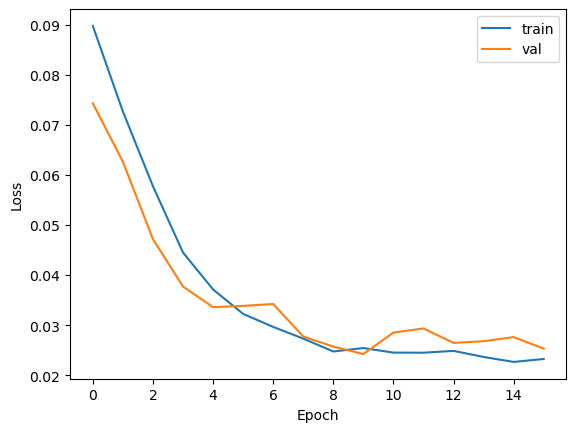

In [10]:
# Plot training loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [12]:
# Make predictions with the model

# Evaluate on chronological validation
xFull = df['center'].values
yFull = df['steeringAngle'].values

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

MSE: 0.019059581685101554
R² : -0.004148926699921951


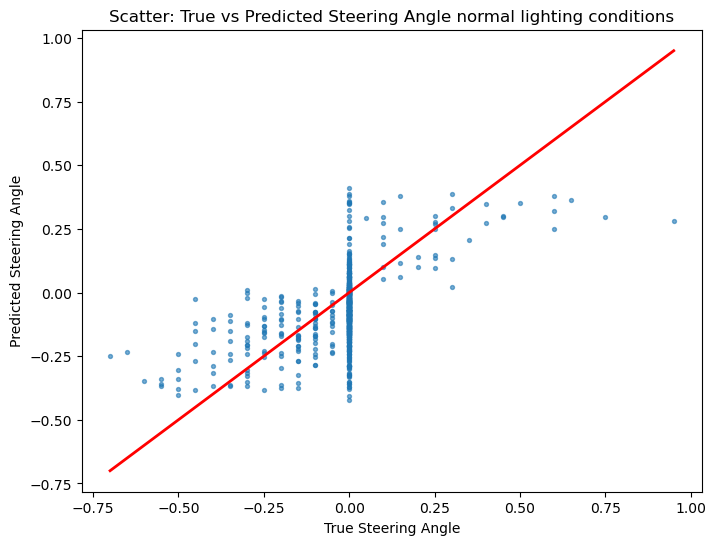

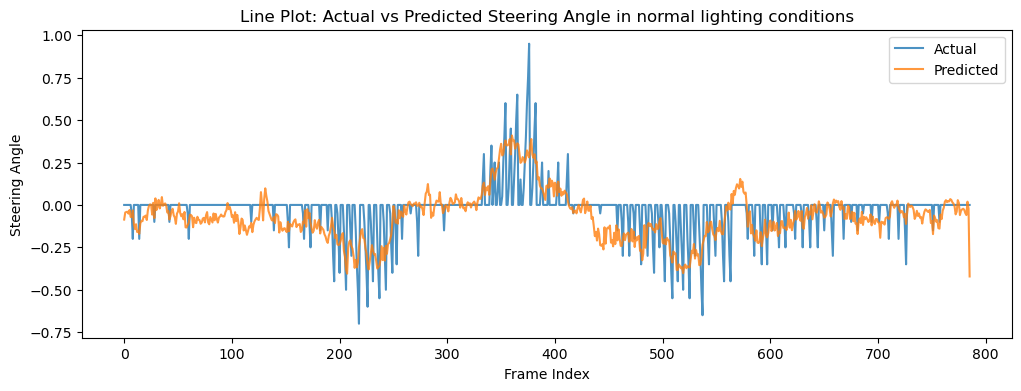

In [13]:
# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

In [14]:
# and this is now our standard model

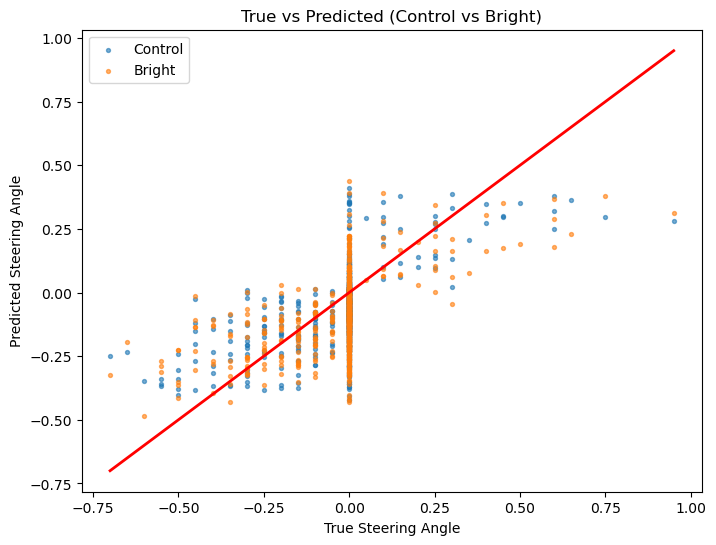

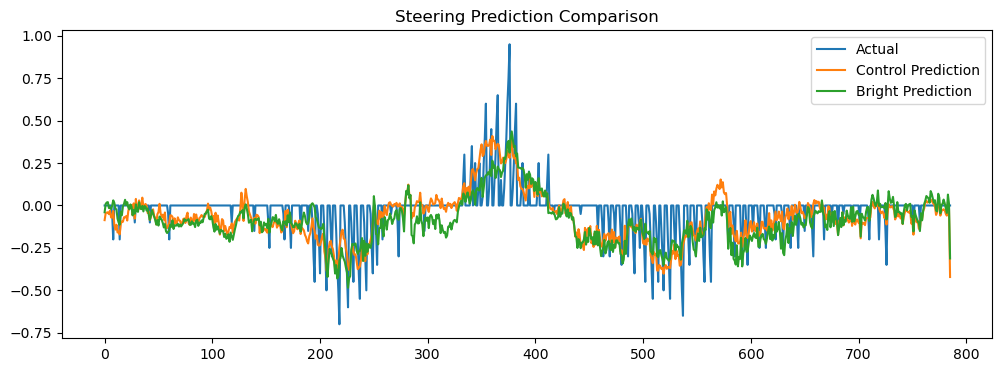

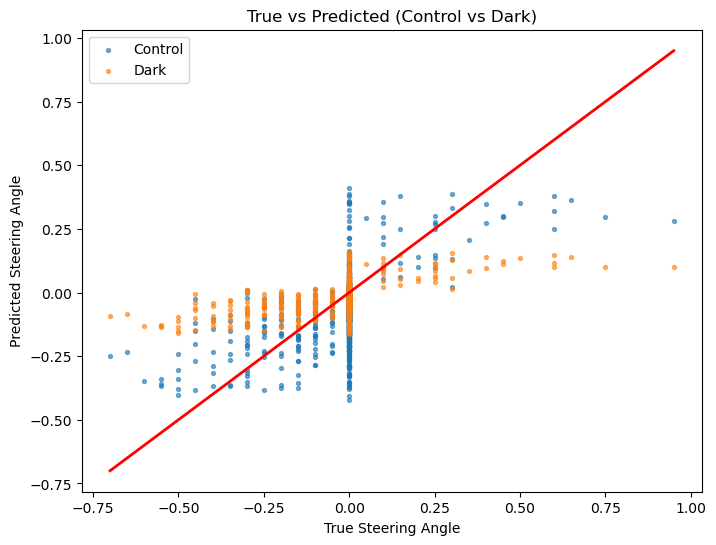

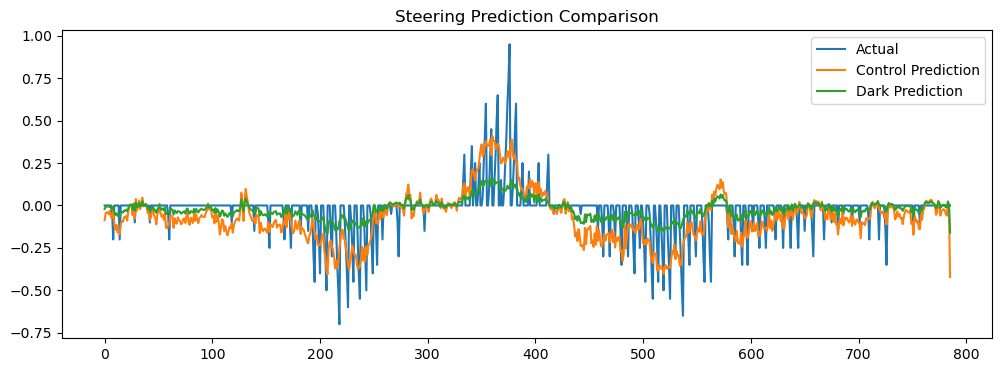

In [16]:
# --- Evaluate on chronological validation (CONTROL) ---
xFull = df['center'].values
yFull = df['steeringAngle'].values

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPredControl = []
yPredBright = []
yPredDark = []

for path in xValReal:
    img = loadImage(path)

    # Control prediction
    predC = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPredControl.append(predC)

    # Brightened version
    imgBright = brightenImage(img, factor=1.8)
    predB = ControlledAnglePredictor.predict(np.expand_dims(imgBright, 0), verbose=0)[0][0]
    yPredBright.append(predB)

    # darkened version
    imgDark = darkenImage(img, factor=0.4)
    predB = ControlledAnglePredictor.predict(np.expand_dims(imgDark, 0), verbose=0)[0][0]
    yPredDark.append(predB)

yPredControl = np.array(yPredControl)
yPredBright  = np.array(yPredBright)
yPredDark  = np.array(yPredDark)

plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPredControl, s=8, label="Control", alpha=0.6)
plt.scatter(yValReal, yPredBright, s=8, label="Bright", alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.legend()
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("True vs Predicted (Control vs Bright)")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual')
plt.plot(yPredControl, label='Control Prediction')
plt.plot(yPredBright, label='Bright Prediction')
plt.legend()
plt.title("Steering Prediction Comparison")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPredControl, s=8, label="Control", alpha=0.6)
plt.scatter(yValReal, yPredDark, s=8, label="Dark", alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.legend()
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("True vs Predicted (Control vs Dark)")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual')
plt.plot(yPredControl, label='Control Prediction')
plt.plot(yPredDark, label='Dark Prediction')
plt.legend()
plt.title("Steering Prediction Comparison")
plt.show()

In [19]:
#making a dataset with birght, normal and dark images (3x the size of the first one)

trainImages = []
trainLabels = []

for _, row in trainDf.iterrows():
    img = loadImage(row["center"])
    angle = row["steeringAngle"]

    # normal
    trainImages.append(img)
    trainLabels.append(angle)

    # bright
    imgBright = brightenImage(img, factor=1.8)
    trainImages.append(imgBright)
    trainLabels.append(angle)

    # dark
    imgDark = darkenImage(img, factor=0.4)
    trainImages.append(imgDark)
    trainLabels.append(angle)

trainImages = np.array(trainImages, dtype=np.float32)
trainLabels = np.array(trainLabels, dtype=np.float32)

print("Training dataset shape:", trainImages.shape, trainLabels.shape)

Training dataset shape: (3696, 66, 200, 3) (3696,)


In [23]:
#Training model no.2 which is trained with bright, normal and dark images
# same architecture as original

AnglePredictorFullPotential = Sequential([
    Input(shape=(66,200,3)),
    Conv2D(24, (5,5), strides=(2,2), activation='relu', input_shape=(66,200,3)),
    Conv2D(36, (5,5), strides=(2,2), activation='relu'),
    Conv2D(48, (5,5), strides=(2,2), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])

AnglePredictorFullPotential.compile(optimizer=Adam(1e-4), loss='mse')
AnglePredictorFullPotential.summary()

# Train using the new and improved dataset

earlyStop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

historyV2 = AnglePredictorFullPotential.fit(
    trainImages, 
    trainLabels,
    batch_size=32,
    epochs=45,
    validation_split=0.2,
    shuffle=True,
    callbacks=[earlyStop]
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0434 - val_loss: 0.0336
Epoch 2/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0320 - val_loss: 0.0319
Epoch 3/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0262 - val_loss: 0.0235
Epoch 4/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0232 - val_loss: 0.0229
Epoch 5/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0202 - val_loss: 0.0205
Epoch 6/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0193 - val_loss: 0.0222
Epoch 7/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0175 - val_loss: 0.0212
Epoch 8/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0152 - val_loss: 0.0220
Epoch 9/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0142 - val_loss: 0.0195
Epoch 10/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0122 - val_loss: 0.0207
Epoch 11/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0109 - val_loss: 0.0213
Epoch 12/45
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0

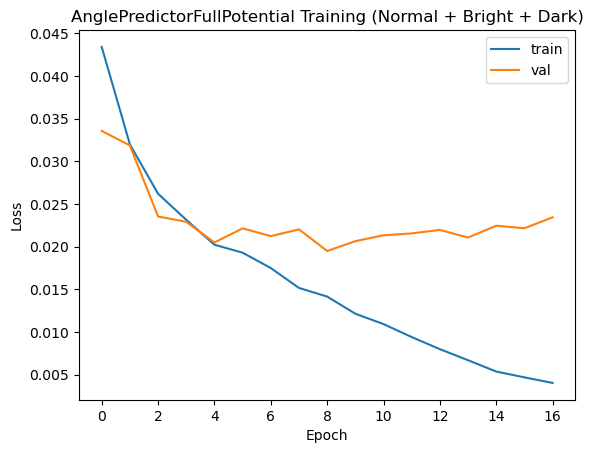

In [24]:
# Plot training curves

plt.plot(historyV2.history['loss'], label='train')
plt.plot(historyV2.history['val_loss'], label='val')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AnglePredictorFullPotential Training (Normal + Bright + Dark)")
plt.show()

AnglePredictorFullPotential.save("AnglePredictorFullPotential.keras")

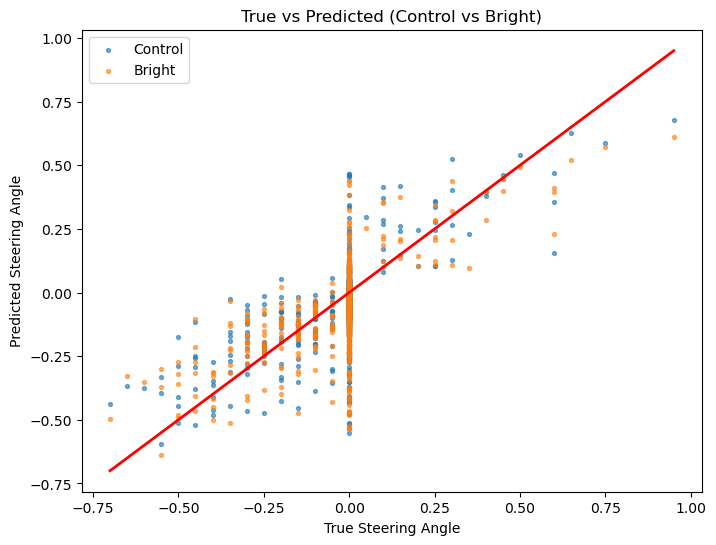

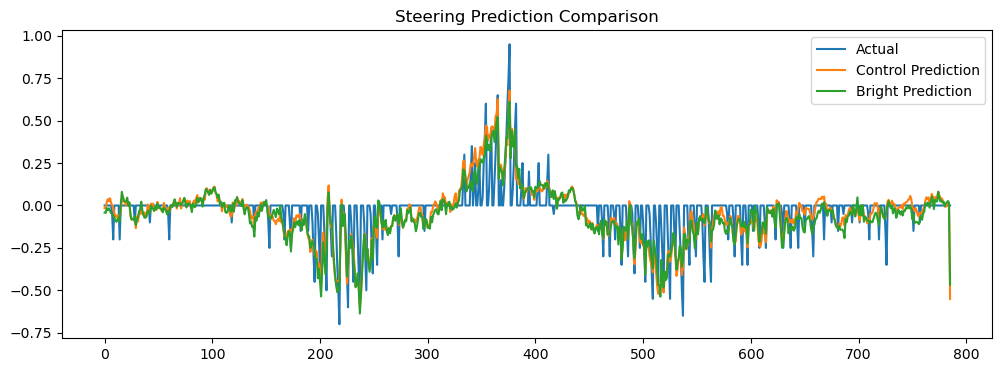

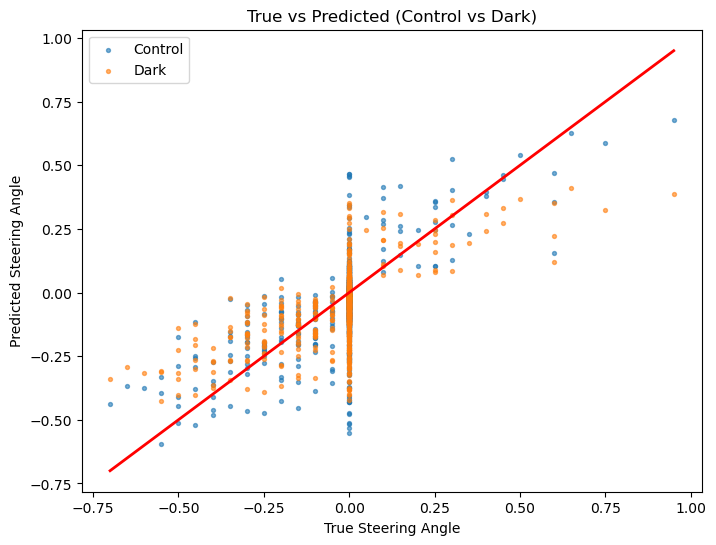

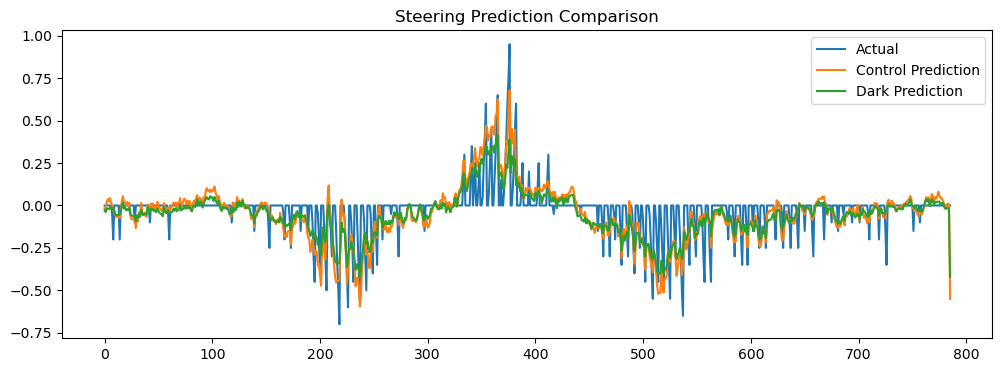

In [25]:
# --- Evaluate on chronological validation (CONTROL) ---
xFull = df['center'].values
yFull = df['steeringAngle'].values

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPredControl = []
yPredBright = []
yPredDark = []

for path in xValReal:
    img = loadImage(path)

    # Control prediction
    predC = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPredControl.append(predC)

    # Brightened version
    imgBright = brightenImage(img, factor=1.8)
    predB = AnglePredictorFullPotential.predict(np.expand_dims(imgBright, 0), verbose=0)[0][0]
    yPredBright.append(predB)

    # darkened version
    imgDark = darkenImage(img, factor=0.4)
    predB = AnglePredictorFullPotential.predict(np.expand_dims(imgDark, 0), verbose=0)[0][0]
    yPredDark.append(predB)

yPredControl = np.array(yPredControl)
yPredBright  = np.array(yPredBright)
yPredDark  = np.array(yPredDark)

plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPredControl, s=8, label="Control", alpha=0.6)
plt.scatter(yValReal, yPredBright, s=8, label="Bright", alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.legend()
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("True vs Predicted (Control vs Bright)")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual')
plt.plot(yPredControl, label='Control Prediction')
plt.plot(yPredBright, label='Bright Prediction')
plt.legend()
plt.title("Steering Prediction Comparison")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPredControl, s=8, label="Control", alpha=0.6)
plt.scatter(yValReal, yPredDark, s=8, label="Dark", alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.legend()
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("True vs Predicted (Control vs Dark)")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual')
plt.plot(yPredControl, label='Control Prediction')
plt.plot(yPredDark, label='Dark Prediction')
plt.legend()
plt.title("Steering Prediction Comparison")
plt.show()